**Lab 4: FIR filters and envelopes**

The goal of this lab is to learn how to implement FIR filters in Python, and how we can use them to improve our synthesis.

In [13]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

**1. Overview of Filtering**

For this lab, we will define an FIR filter as a discrete-time system that converts an input signal $x[n]$ into an output signal $y[n]$ by means of the weighted summation:

$$
y[n] = \sum_{k=0}^M b_kx[n-k]
$$

The function *np.convolve()* is a generic function with which to implement FIR filters. The following code implements a three-point averaging system:

In [5]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
b = np.array([1.0/3, 1.0/3, 1.0/3])
y = np.convolve(b, x)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

1.1 Explain the filtering action of the 5-point averager by comparing the plot of the input $x[n]$ and the output $y[n]$. This filter might be called a “smoothing” filter. Note how the transitions from one level to another have been “smoothed.”

The 5-point averager, is used to smooth or average a signal. It operates by averaging the current sample and four previous samples from the input signal to create a smoother output. This filtering action reduces the impact of high-frequency noise and sharp transitions in the input. We can see this from the example above by noteching how the transitions last longer and have less of an angle of attack. It's an overall smoother graphic than the blue one.

*1.2* Define a function `averaging_filter(x, N)` which implements the N-points averaging filter using the `np.convolve` function.

In [6]:
def averaging_filter(x, N):
    """
    Applies an N-point averaging filter to the input signal x.

    Parameters
    ----------
    x : np.array
        Input signal
    N : int
        Number of points in the averaging window

    Returns
    -------
    y : np.array
        Filtered output (same length as x)
    """
    b = np.ones(N) / N
    y = np.convolve(x, b, mode='same')
    return y




1.3 Run the example above using the `averaging_filter` instead. Change the number N to different values and explain what happen.

In [ ]:
# Write your code here
fs = 1
x = np.array([np.floor(t / 10) for t in range(50)])

# Test different N
for N in [3, 5, 10]:
    y = averaging_filter(x, N)
    plot_signals([x, y], sr=fs, name=['input x[n]', f'{N}-point avg'], mode='lines+markers')

1.4 How would you classify this filter, as a low-pass o high-pass filter?

Es tracta d'un filtre de low-pass perquè fa una mitjana de mostres properes, suprimint canvis ràpids (freqüències altes) mentre preserva tendències lentes (freqüències baixes).







---

**2. Envelope detector**

Now we'll implement an envelope detector by concatenating two systems: a full-wave rectifier (absolute value) and the N-point averaging filter.

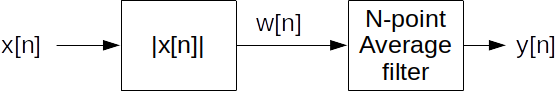

2.1 Define a function `envelope(x, N)` which applies an N-point averaging filter to the full-wave rectified signal and returns the output $y[n]$.

**Note 1**: to calculate the full-wave rectified signal check the `np.abs()` function.

**Note 2**: The output should have the same length as the input signal. Use 'same' mode (see [np.convolve](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) documentation).

In [9]:
def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    rectified = np.abs(x)
    y = averaging_filter(rectified, N)
    return y
    


2.2 Load your reference signal and calculate its envelope using the function you designed. Plot the reference signal and envelope in the same figure.

In [16]:
# Load your reference audio (update path if needed)
x_ref, fs_ref = load_audio('audio/reference.wav')  

# Compute envelope
N = 500
env = envelope(x_ref, N)

# Plot (first 0.1 seconds for clarity)
duration_to_plot = 0.1  # seconds
plot_signals(
    [x_ref, env],
    sr=fs_ref,
    t_end=duration_to_plot,
    name=['Reference signal', 'Envelope'],
    mode='lines'
)

2.3 Change the number N to get a good result. What happens when you change the number N?

    Si N és petit (per exemple, 20):
    El sobre (la corba que envolta el senyal) queda massa dentat i encara mostra moltes de les oscil·lacions ràpides del senyal original. No s’ha suavitzat prou. 

    Si N és gran (per exemple, 500):
    El sobre queda molt suau, però reacciona massa lentament als canvis del senyal. Per exemple, no capta bé quan el so comença (atac) o quan s’apaga (decaïment). 

    Si N és el just (per exemple, entre 80 i 150 quan la freqüència de mostratge és 16 kHz):
    El sobre segueix bé els canvis d’intensitat del senyal (com puja i baixa el volum), sense quedar dentat ni retardar-se. És el punt just! 
     

2.4 Explain with your own words why this system achieves extracting the envelope. It might be useful to plot together the signals $x[n]$, $w[n]$ and $y[n]$.

In [18]:

# Plot x[n], |x[n]|, and envelope
N_test = 100
w = np.abs(x_ref)
y_env = envelope(x_ref, N_test)

# Plot short segment
plot_signals(
    [x_ref, w, y_env],
    sr=fs_ref,
    t_end=0.05,
    name=['x[n]', '|x[n]|', 'envelope'],
    mode='lines'
)

2.5 Now let's apply this envelope to the synthesized signal. Copy the code from Lab3 Ex. 2.1 and generate the synthesized signal. Then multiply the synthesized signal by the envelope. Note that both signal and envelope should have the same length. You can define a time vector of the same length of the envelope to create the signal:

In [25]:
# 1. Carregar la senyal de referència (si encara no està carregada)
# Ajusta la ruta si cal
reference, fs = load_audio('audio/reference.wav')

# 2. Definir els paràmetres de síntesi (dels valors que em has donat)
f0 = 193.78  # Freqüència fonamental en Hz
weights = [1, 0.1087, 0.0296, 0.0413, 0.0259, 0.0068, 0.0006, 0.0004]  # Ak per a k=1..8
phi = 0  # Fase inicial

# 3. Vector de temps amb la mateixa durada i fs que la referència
t = np.arange(len(reference)) / fs

# 4. Funció de síntesi (cal que estigui definida!)
# Si no la tens, aquí en tens una implementació:
def synthesize(f0, phi, weights, t):
    """
    Sintetitza una senyal periòdica com a suma de sinusoïdals harmòniques.
    
    Parameters
    ----------
    f0 : float
        Freqüència fonamental (Hz)
    phi : float
        Fase inicial (radians)
    weights : list
        Amplituds relatives dels harmònics (A1, A2, ..., Ak)
    t : np.array
        Vector de temps
        
    Returns
    -------
    signal : np.array
        Senyal sintetitzada
    """
    signal = np.zeros_like(t)
    for k, Ak in enumerate(weights, start=1):
        signal += Ak * np.sin(2 * np.pi * k * f0 * t + phi)
    return signal

# 5. Sintetitzar la senyal
synthesized = synthesize(f0, phi, weights, t)

# 6. Calcular l'envolupant de la senyal de referència
# (Fes servir un valor de N adequat, per exemple N=100 per a fs=16000 Hz)
N = 100  # Ajusta si cal segons la teva fs
env = envelope(reference, N)

# 7. Assegurar que totes les senyals tenen la mateixa longitud
min_len = min(len(synthesized), len(env))
synthesized = synthesized[:min_len]
env = env[:min_len]

# 8. Aplicar l'envolupant a la senyal sintetitzada
synthesized_with_env = synthesized * env



# Comparar les tres senyals (referència, sintetitzada neta, i sintetitzada amb envolupant)
# Plot: primer 0.5 segons per veure bé l'efecte de l'envolupant
plot_signals(
    [reference, synthesized, synthesized_with_env],
    fs,
    t_start=0,
    t_end=0.5,
    name=['Reference', 'Synthesized', 'Synth + Envelope'],
    mode='lines'
)

2.6. Compare the spectrograms of the reference signal and the synthesized signal. What are the main differences?

Espectrograma de la senyal de referència:


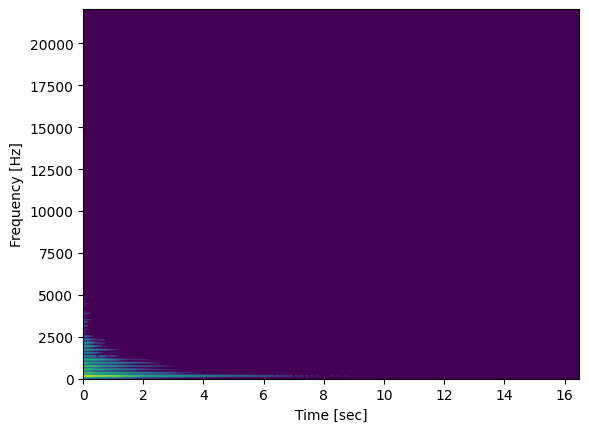

Espectrograma de la senyal sintetitzada amb envolupant:


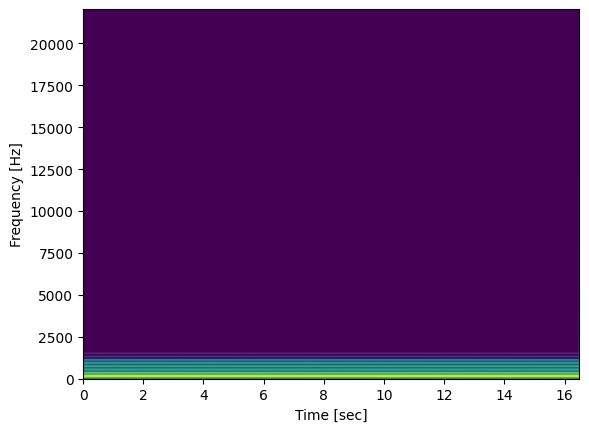

In [27]:
# 1. Carregar les dues senyals
reference, fs_ref = load_audio('audio/reference.wav')
synthesized_env, fs_synth = load_audio('audio/synthesized.wav')

# 2. Assegurar que les freqüències de mostratge coincideixen (haurien de ser iguals)
assert fs_ref == fs_synth, "Les freqüències de mostratge han de ser iguals!"
fs = fs_ref

# 3. Calcular els espectogrames amb STFT
# Paràmetres comuns per a una bona resolució temporal i espectral
n_fft = 1024      # Nombre de punts per a la FFT
hop_length = 256  # Desplaçament entre finestres (afecta resolució temporal)

# STFT per a la senyal de referència
S_ref = librosa.stft(reference, n_fft=n_fft, hop_length=hop_length)
# Magnitud al quadrat (potència)
power_ref = np.abs(S_ref) ** 2

# STFT per a la senyal sintetitzada amb envolupant
S_synth = librosa.stft(synthesized_env, n_fft=n_fft, hop_length=hop_length)
power_synth = np.abs(S_synth) ** 2

# 4. Vectors d'eixos per als plots
# Frequències (Hz)
freqs = librosa.fft_frequencies(sr=fs, n_fft=n_fft)
# Temps (segons)
times_ref = librosa.frames_to_time(np.arange(S_ref.shape[1]), sr=fs, hop_length=hop_length)
times_synth = librosa.frames_to_time(np.arange(S_synth.shape[1]), sr=fs, hop_length=hop_length)

# 5. Plot dels espectogrames
print("Espectrograma de la senyal de referència:")
plot_spectrogram(freqs, times_ref, power_ref)
plt.show()

print("Espectrograma de la senyal sintetitzada amb envolupant:")
plot_spectrogram(freqs, times_synth, power_synth)
plt.show()

2.7 Listen to the synthesized signal and compare it to the reference.



In [ ]:
# Write your code here

In [ ]:
# Write your code here